<a href="https://colab.research.google.com/github/dandan8585/challenge-parte-2-telecom-Danger-Malaga/blob/main/Challenge_Telecom_X_2_danger_malaga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXTRACCIÓN

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# To fix the 'HTTP Error 401: Unauthorized', please make sure the file is publicly shared on Google Drive
# and then use a direct download link. A common way is to change the 'view?usp=drive_link'
# part of the URL to 'uc?export=download'.
# For example, if your link is 'https://drive.google.com/file/d/1nxRpIspGp_v5XOsRWZ5q1JLM8MPY1TX2/view?usp=drive_link',
# change it to 'https://drive.google.com/uc?export=download&id=1nxRpIspGp_v5XOsRWZ5q1JLM8MPY1TX2'

# Replace the placeholder URL with your actual direct download link
df = pd.read_csv('https://drive.google.com/uc?export=download&id=1nxRpIspGp_v5XOsRWZ5q1JLM8MPY1TX2')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [3]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


 Pre procesamiento

In [5]:
df = df.drop(columns=['CustomerID'])


In [6]:
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


In [7]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

In [8]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## EDA

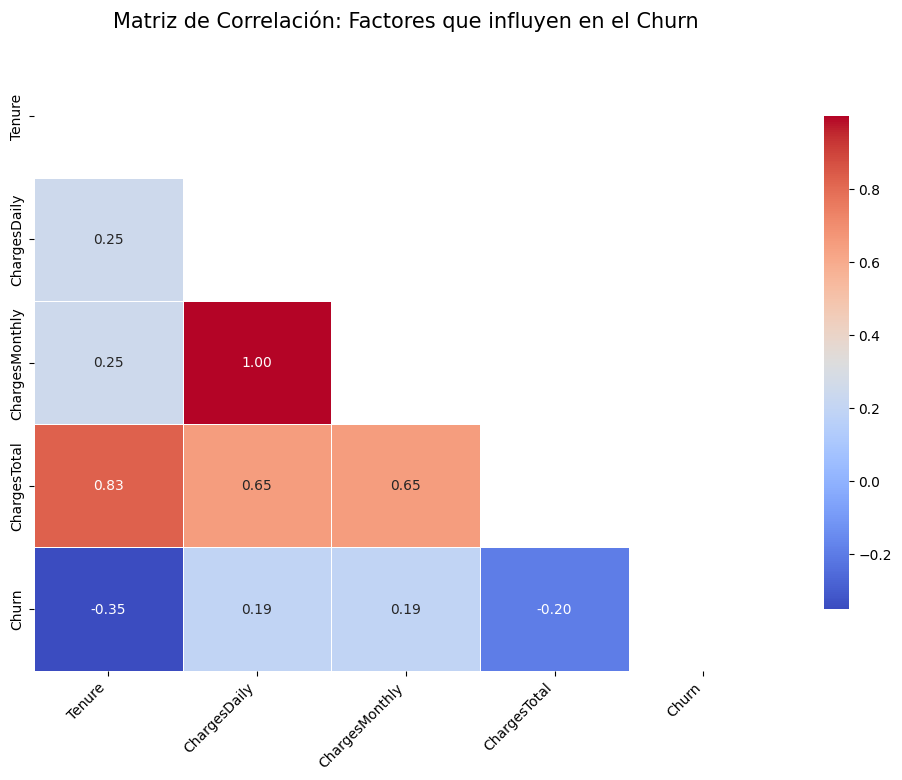

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Preparar datos (solo columnas numéricas + el target)
# Es buena práctica crear una copia para no alterar el df original por accidente
df_numeric = df.select_dtypes(include=["int64", "float64"]).copy()
df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# 2. Calcular matriz
corr_matrix = df_numeric.corr()

# 3. Crear una máscara para el triángulo superior (opcional, pero se ve genial)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Configurar visualización
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,           # Aplicamos la máscara
    annot=True,          # Mostramos los números
    cmap="coolwarm",     # Azul (negativo) a Rojo (positivo)
    fmt=".2f",           # 2 decimales
    linewidths=0.5,      # Espacio entre celdas
    cbar_kws={"shrink": .8} # Ajustar el tamaño de la barra de color
)

plt.title("Matriz de Correlación: Factores que influyen en el Churn", fontsize=15, pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

In [10]:
df = df.drop(columns=["ChargesDaily","ChargesTotal"])

2.-  Analisis de churn por categoria

- variables categoria

In [11]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

- proporción por categoria

In [12]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


📌 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


**** Qui-cuadrado (Chi-Square Test) ****

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
df_rank = df.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [14]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]

print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [15]:
df = df.drop(columns=["Gender", "PhoneService"])

**ROC-AUC**

In [16]:
from sklearn.metrics import roc_auc_score, roc_curve

In [46]:
# Calculate prediction probabilities for Logistic Regression model
y_prob_lr = log_model.predict_proba(X_test_processed)[:, 1]

# Calculate prediction probabilities for Random Forest model
y_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

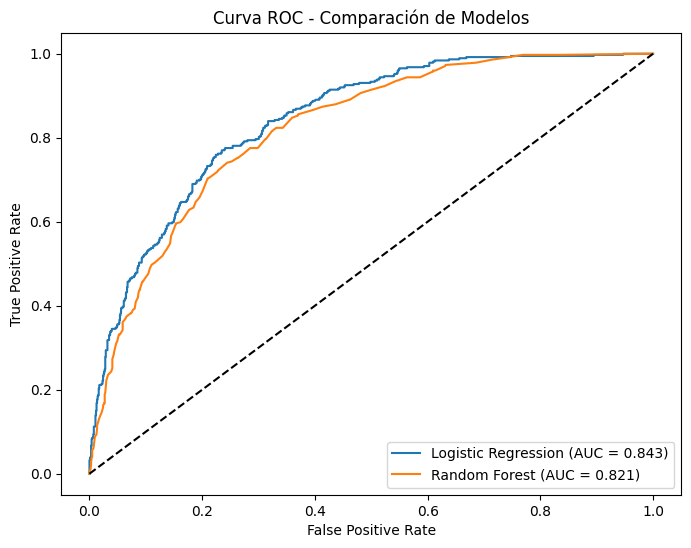

In [47]:
plt.figure(figsize=(8,6))

# Calculate AUC scores
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

plt.plot([0,1], [0,1], 'k--')  # línea modelo aleatorio

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend()
plt.show()

**Split**

In [20]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


split **2**

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


One-Hot Encoding **3**

In [33]:
# Aplicar One-Hot Encoding en treno
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar en teste
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantir que treno y teste tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [24]:
X_train.head()

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False
3926,33,74.75,False,True,True,False,False,False,True,False,True,False,True,True,True,False,False,True,False,False
3859,14,86.00,False,False,True,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True


In [25]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5634 entries, 3793 to 5679
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Tenure                                 5634 non-null   int64  
 1   ChargesMonthly                         5634 non-null   float64
 2   SeniorCitizen_Yes                      5634 non-null   bool   
 3   Partner_Yes                            5634 non-null   bool   
 4   Dependents_Yes                         5634 non-null   bool   
 5   MultipleLines_Yes                      5634 non-null   bool   
 6   InternetService_Fiber optic            5634 non-null   bool   
 7   InternetService_No                     5634 non-null   bool   
 8   OnlineSecurity_Yes                     5634 non-null   bool   
 9   OnlineBackup_Yes                       5634 non-null   bool   
 10  DeviceProtection_Yes                   5634 non-null   bool   
 11  TechSu

 Verificar desbalanceamiento **4**

In [26]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
No,73.464679
Yes,26.535321


Entrenamiento ㊗

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pandas as pd

# Ensure y_train and y_test are numerical (0 and 1)
# Assuming 'Yes' corresponds to 1 and 'No' to 0
y_train = y_train.map({"Yes": 1, "No": 0})
y_test = y_test.map({"Yes": 1, "No": 0})

# Re-apply One-Hot Encoding on X_train and X_test just before fitting,
# as the kernel state indicates object columns are still present after previous processing.
X_train_processed = pd.get_dummies(X_train, drop_first=True)
X_test_processed = pd.get_dummies(X_test, drop_first=True)

# Ensure X_train_processed and X_test_processed have the same columns
X_train_processed, X_test_processed = X_train_processed.align(X_test_processed, join='left', axis=1, fill_value=0)


log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_processed, y_train)

y_pred_log_normal = log_model.predict(X_test_processed)

print("Regresion logistica")
print(classification_report(y_test, y_pred_log_normal))

Regresion logistica
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



 Random Forest Modelo 2

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd

# Ensure y_train and y_test are numerical (0 and 1) if not already
# This line is added defensively, in case the previous cell was not executed or reset.
# If it has been executed, mapping again won't change numerical values.
if y_train.dtype == 'object':
    y_train = y_train.map({"Yes": 1, "No": 0})
if y_test.dtype == 'object':
    y_test = y_test.map({"Yes": 1, "No": 0})

# Apply One-Hot Encoding to X_train and X_test for the Random Forest model
X_train_rf = pd.get_dummies(X_train, drop_first=True)
X_test_rf = pd.get_dummies(X_test, drop_first=True)

# Ensure X_train_rf and X_test_rf have the same columns
X_train_rf, X_test_rf = X_train_rf.align(X_test_rf, join='left', axis=1, fill_value=0)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_rf, y_train)

y_pred_rf = rf_model.predict(X_test_rf)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import pandas as pd

# Ensure y_train and y_test are numerical (0 and 1) if not already
# This is a defensive step, as they should be numerical from the previous cell.
if y_train.dtype == 'object':
    y_train = y_train.map({"Yes": 1, "No": 0})
if y_test.dtype == 'object':
    y_test = y_test.map({"Yes": 1, "No": 0})

# Apply One-Hot Encoding to X_train and X_test
X_train_processed = pd.get_dummies(X_train, drop_first=True)
X_test_processed = pd.get_dummies(X_test, drop_first=True)

# Ensure X_train_processed and X_test_processed have the same columns
X_train_processed, X_test_processed = X_train_processed.align(X_test_processed, join='left', axis=1, fill_value=0)

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_processed, y_train)

y_pred_log = log_model.predict(X_test_processed)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



Evaluación

<Axes: >

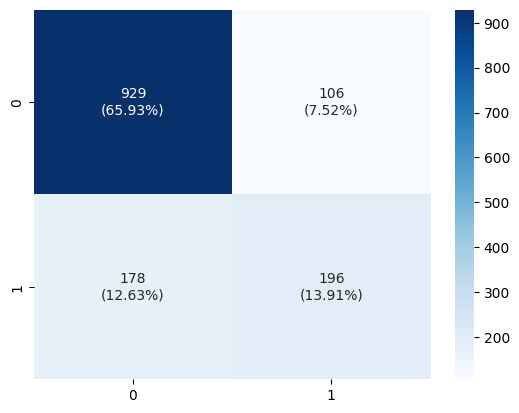

In [49]:
# matriz de confuncion
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
labels = [f"{v1}\n({v2})" for v1, v2 in zip(group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

sns.heatmap(cm, annot=labels, fmt="", cmap="Blues")

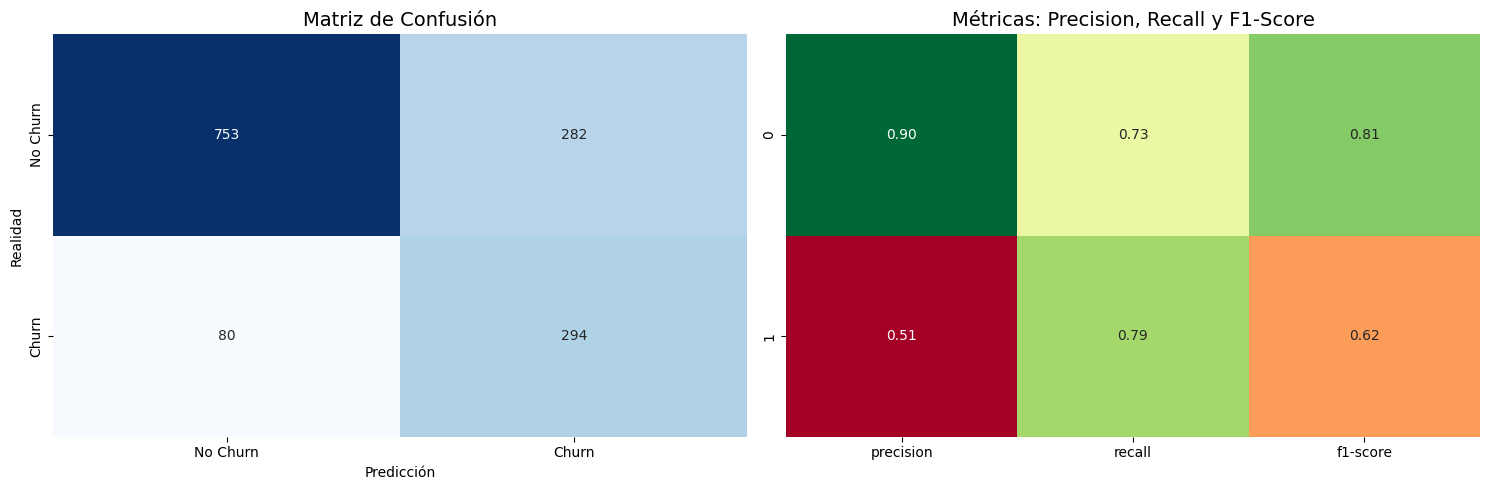


Detalle del Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Obtener métricas
cm = confusion_matrix(y_test, y_pred_log)
report = classification_report(y_test, y_pred_log, output_dict=True)

# 2. Crear visualización combinada (Matriz + Tabla de Reporte)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# --- LADO IZQUIERDO: MATRIZ DE CONFUSIÓN ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False)
ax[0].set_title('Matriz de Confusión', fontsize=14)
ax[0].set_xticklabels(['No Churn', 'Churn'])
ax[0].set_yticklabels(['No Churn', 'Churn'])
ax[0].set_xlabel('Predicción')
ax[0].set_ylabel('Realidad')

# --- LADO DERECHO: REPORTE DE CLASIFICACIÓN (Como Heatmap) ---
# Convertimos el reporte a un DataFrame para que se vea bonito
report_df = pd.DataFrame(report).iloc[:-1, :2].T # Excluimos accuracy y soporte total para enfoque

sns.heatmap(report_df, annot=True, cmap='RdYlGn', cbar=False, ax=ax[1], fmt='.2f')
ax[1].set_title('Métricas: Precision, Recall y F1-Score', fontsize=14)

plt.tight_layout()
plt.show()

# 3. Mostrar el reporte de texto tradicional (opcional, pero útil para logs)
print("\nDetalle del Reporte de Clasificación:")
print(classification_report(y_test, y_pred_log))

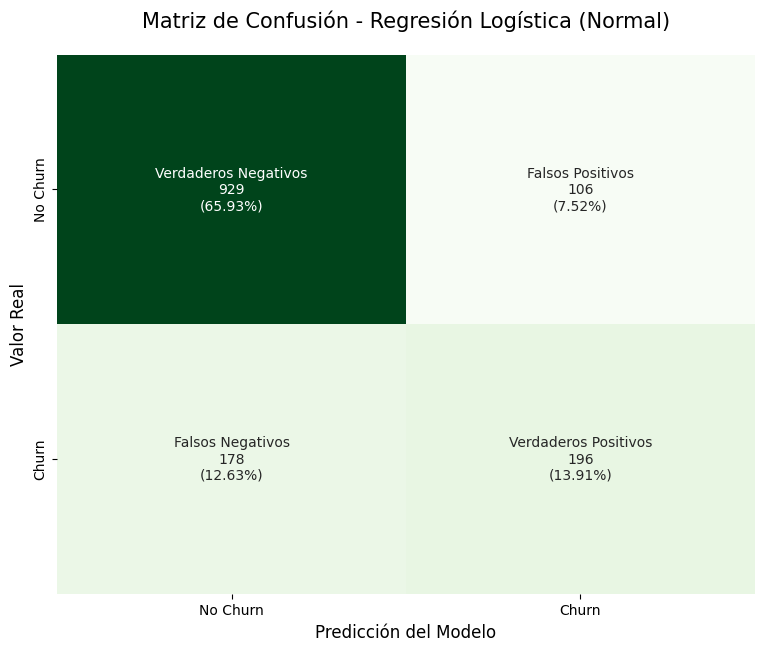

In [36]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular la matriz
cm = confusion_matrix(y_test, y_pred_log_normal)

# 2. Preparar etiquetas con cantidades y porcentajes
# Esto ayuda a entender el peso de los errores (Falsos Positivos vs Falsos Negativos)
group_names = ['Verdaderos Negativos','Falsos Positivos','Falsos Negativos','Verdaderos Positivos']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

labels = [f"{v1}\n{v2}\n({v3})" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

# 3. Crear el gráfico
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=labels,       # Usamos nuestras etiquetas personalizadas
    fmt="",             # Evita errores de formato con strings
    cmap='Greens',      # Color verde para diferenciarlo del modelo balanceado
    cbar=False
)

# 4. Estética final
plt.title("Matriz de Confusión - Regresión Logística (Normal)", fontsize=15, pad=20)
plt.xlabel("Predicción del Modelo", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)
plt.xticks([0.5, 1.5], ["No Churn", "Churn"])
plt.yticks([0.5, 1.5], ["No Churn", "Churn"])

plt.show()

Comparación formal de modelos

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [38]:
y_pred_lr = log_model.predict(X_test_processed)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

In [39]:
y_pred_rf = rf_model.predict(X_test_rf)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

In [48]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1-Score": [f1_lr, f1_rf],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf]
})

display(comparison_df)

,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.743080,0.510417,0.786096,0.618947,0.842587
1,Random Forest,0.784244,0.622378,0.475936,0.539394,0.821100


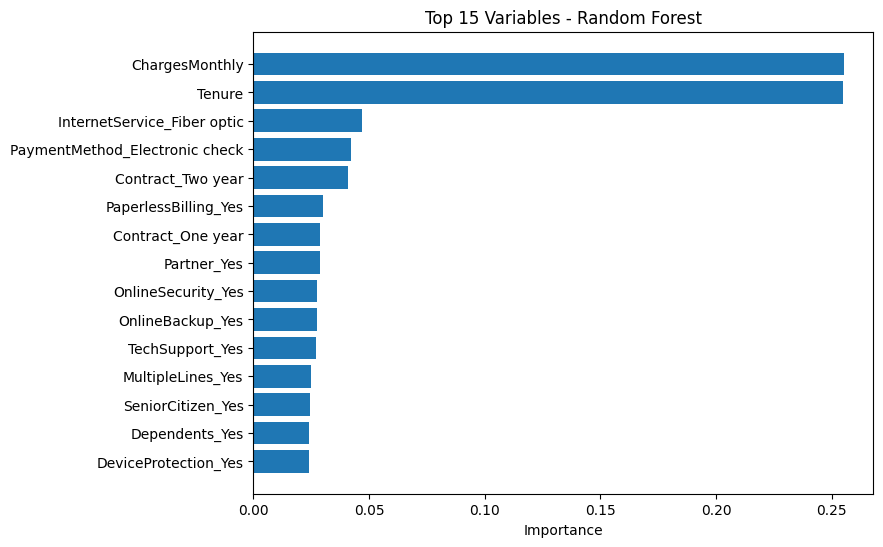

In [50]:
# Get feature importances from the Random Forest model
feature_importances = rf_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Variable': X_train_rf.columns,
    'Importance': feature_importances
})

# Sort the DataFrame by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,6))
plt.barh(
    feature_importance_df["Variable"].head(15)[::-1],
    feature_importance_df["Importance"].head(15)[::-1]
)
plt.title("Top 15 Variables - Random Forest")
plt.xlabel("Importance")
plt.show()

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Variable": X_train_rf.columns,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

feature_importance_df.head(15)

,Variable,Importance
1,ChargesMonthly,0.255088
0,Tenure,0.254962
6,InternetService_Fiber optic,0.046920
18,PaymentMethod_Electronic check,0.042238
15,Contract_Two year,0.041042
16,PaperlessBilling_Yes,0.030306
14,Contract_One year,0.029001
3,Partner_Yes,0.028666
8,OnlineSecurity_Yes,0.027619
9,OnlineBackup_Yes,0.027347


In [52]:
coef_df = pd.DataFrame({
    "Variable": X_train_processed.columns,
    "Coeficiente": log_model.coef_[0]
})

coef_df["Abs_Coef"] = coef_df["Coeficiente"].abs()

coef_df = coef_df.sort_values(by="Abs_Coef", ascending=False)

coef_df.head(15)

,Variable,Coeficiente,Abs_Coef
15,Contract_Two year,-1.386755,1.386755
6,InternetService_Fiber optic,1.314570,1.314570
7,InternetService_No,-1.294736,1.294736
14,Contract_One year,-0.708311,0.708311
12,StreamingTV_Yes,0.504591,0.504591
18,PaymentMethod_Electronic check,0.429403,0.429403
13,StreamingMovies_Yes,0.414177,0.414177
5,MultipleLines_Yes,0.404301,0.404301
16,PaperlessBilling_Yes,0.338989,0.338989
11,TechSupport_Yes,-0.265910,0.265910


Text(0.5, 1.0, 'Distribución de Cargos Mensuales vs Churn')

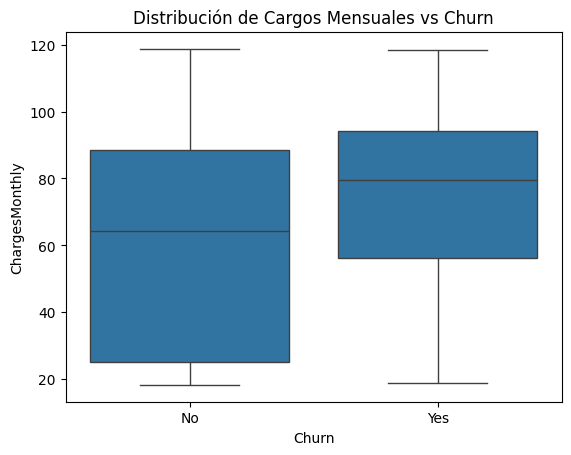

In [53]:
import seaborn as sns
sns.boxplot(x="Churn", y="ChargesMonthly", data=df)
plt.title("Distribución de Cargos Mensuales vs Churn")

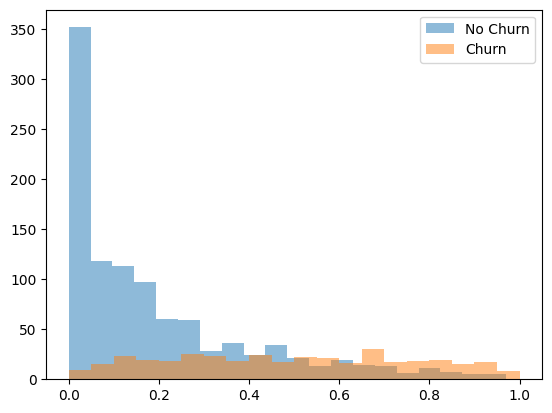

In [54]:
plt.hist(y_prob_rf[y_test==0], bins=20, alpha=0.5, label="No Churn")
plt.hist(y_prob_rf[y_test==1], bins=20, alpha=0.5, label="Churn")
plt.legend()

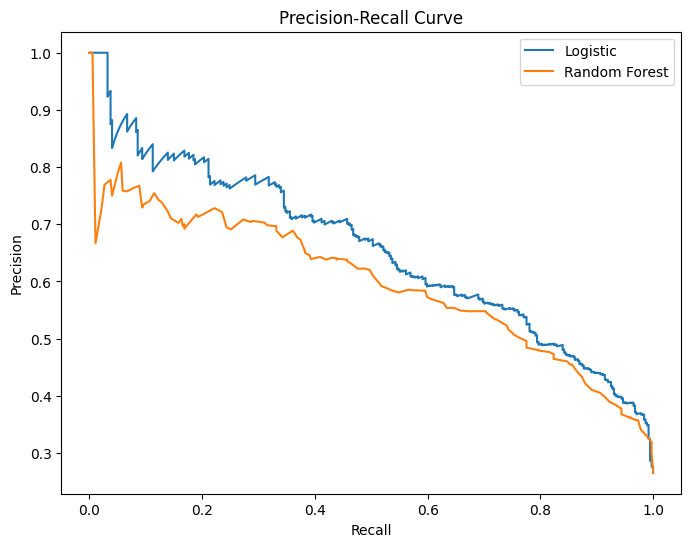

In [55]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(recall_lr, precision_lr, label="Logistic")
plt.plot(recall_rf, precision_rf, label="Random Forest")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()